In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import plotly.express as px

import plotly.graph_objects as go

In [13]:
df = pd.read_csv("/content/ncr_ride_bookings.csv")

/tmp/ipykernel_4045/3653899246.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/ncr_ride_bookings.csv")


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152181 entries, 0 to 152180
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               152180 non-null  object 
 1   Time                               152180 non-null  object 
 2   Booking ID                         152180 non-null  object 
 3   Booking Status                     152180 non-null  object 
 4   Customer ID                        152180 non-null  object 
 5   Vehicle Type                       152181 non-null  object 
 6   Pickup Location                    152181 non-null  object 
 7   Drop Location                      152181 non-null  object 
 8   Avg VTAT                           141521 non-null  float64
 9   Avg CTAT                           103464 non-null  object 
 10  Cancelled Rides by Customer        10637 non-null   float64
 11  Reason for cancelling by Customer  1063

In [16]:
df.isnull()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,False,False,False,False,False,False,False,False,True,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152176,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
152177,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
152178,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
152179,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False


There are no null values in dataset.

In [17]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [18]:
df.isnull().sum()

,0
Date,1
Time,1
Booking ID,1
Booking Status,1
Customer ID,1
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10660
Avg CTAT,48717


In [19]:
df.describe()

,Avg VTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,141521.000000,10637.0,27420.0,9126.0,103462.000000,103462.000000,94336.000000,94336.000000
mean,8.453643,1.0,1.0,1.0,508.362355,24.635814,4.231175,4.404645
std,3.773016,0.0,0.0,0.0,395.863943,14.004157,0.436883,0.437691
min,2.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,1.0,1.0,1.0,414.000000,23.710000,4.300000,4.500000
75%,11.300000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


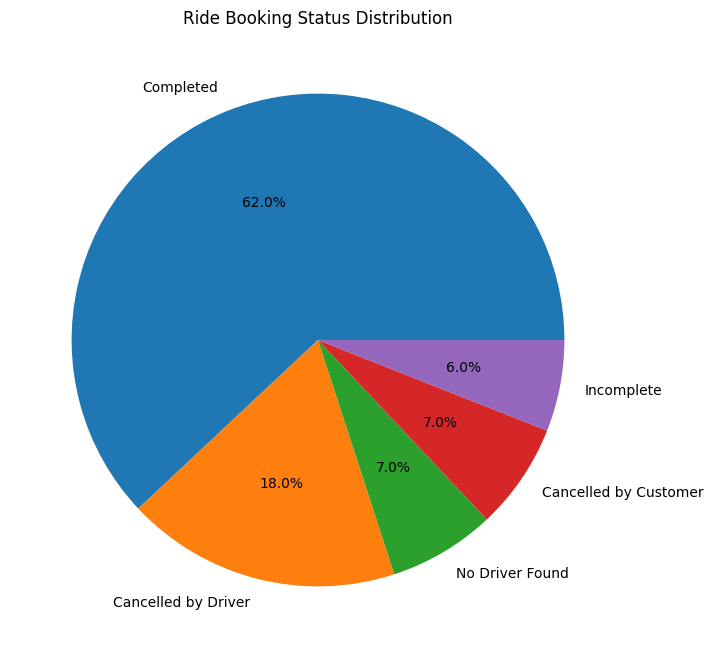

In [22]:
status = df['Booking Status'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(status.values,
        labels=status.index,
        autopct='%1.1f%%')

plt.title('Ride Booking Status Distribution')
plt.show()

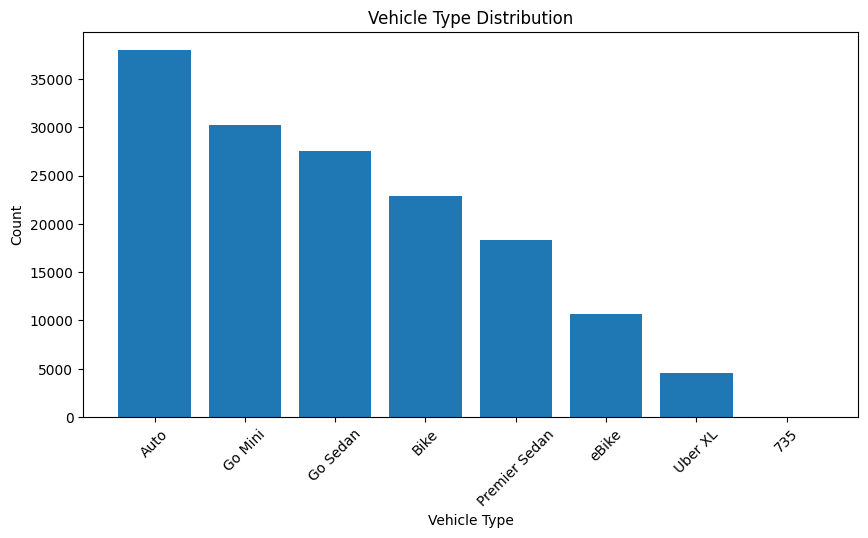

In [23]:
vehicle = df['Vehicle Type'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(vehicle.index, vehicle.values)

plt.xticks(rotation=45)
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.title('Vehicle Type Distribution')

plt.show()

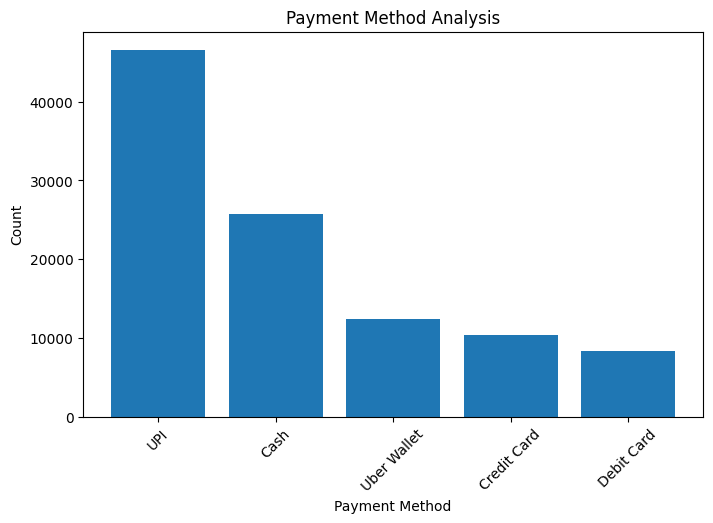

In [24]:
payment = df['Payment Method'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(payment.index, payment.values)

plt.xticks(rotation=45)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method Analysis')

plt.show()

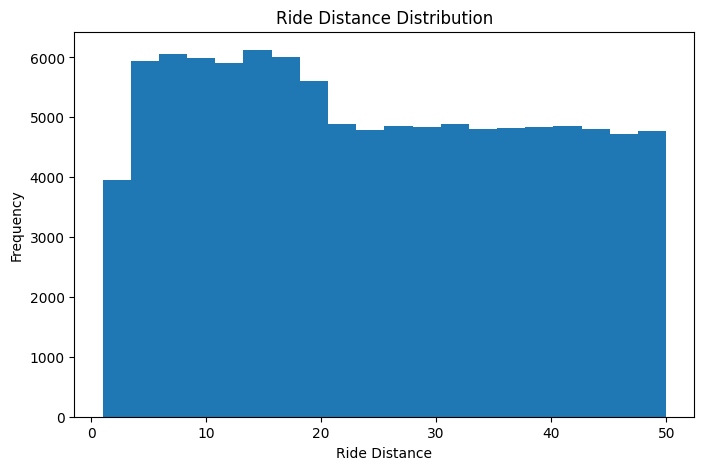

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df['Ride Distance'].dropna(),
         bins=20)

plt.xlabel('Ride Distance')
plt.ylabel('Frequency')
plt.title('Ride Distance Distribution')

plt.show()

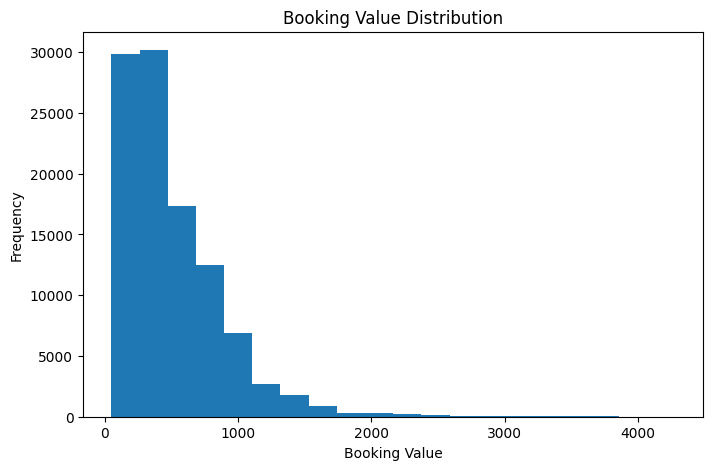

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df['Booking Value'].dropna(),
         bins=20)

plt.xlabel('Booking Value')
plt.ylabel('Frequency')
plt.title('Booking Value Distribution')

plt.show()

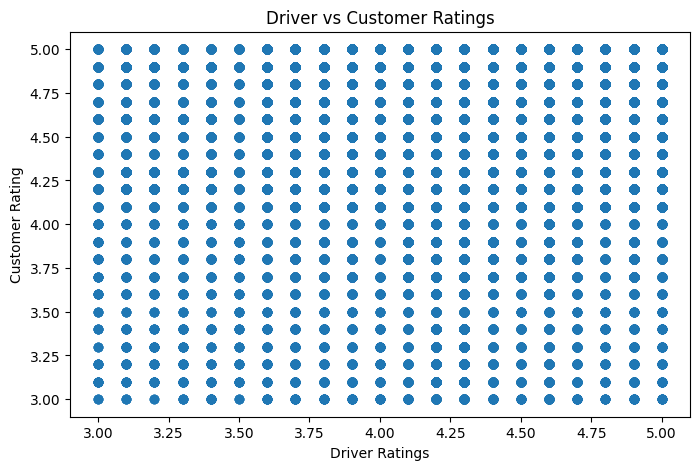

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(df['Driver Ratings'],
            df['Customer Rating'])

plt.xlabel('Driver Ratings')
plt.ylabel('Customer Rating')

plt.title('Driver vs Customer Ratings')

plt.show()

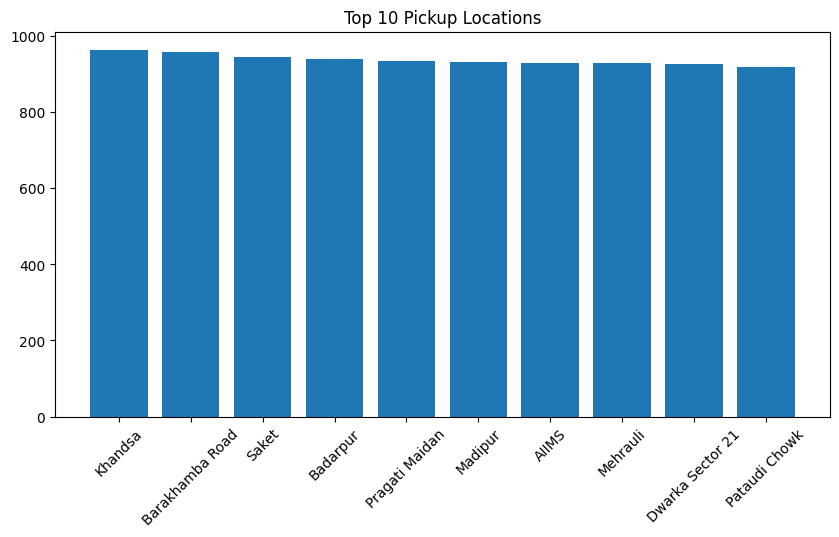

In [28]:
pickup = df['Pickup Location'].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(pickup.index,pickup.values)

plt.xticks(rotation=45)

plt.title('Top 10 Pickup Locations')

plt.show()

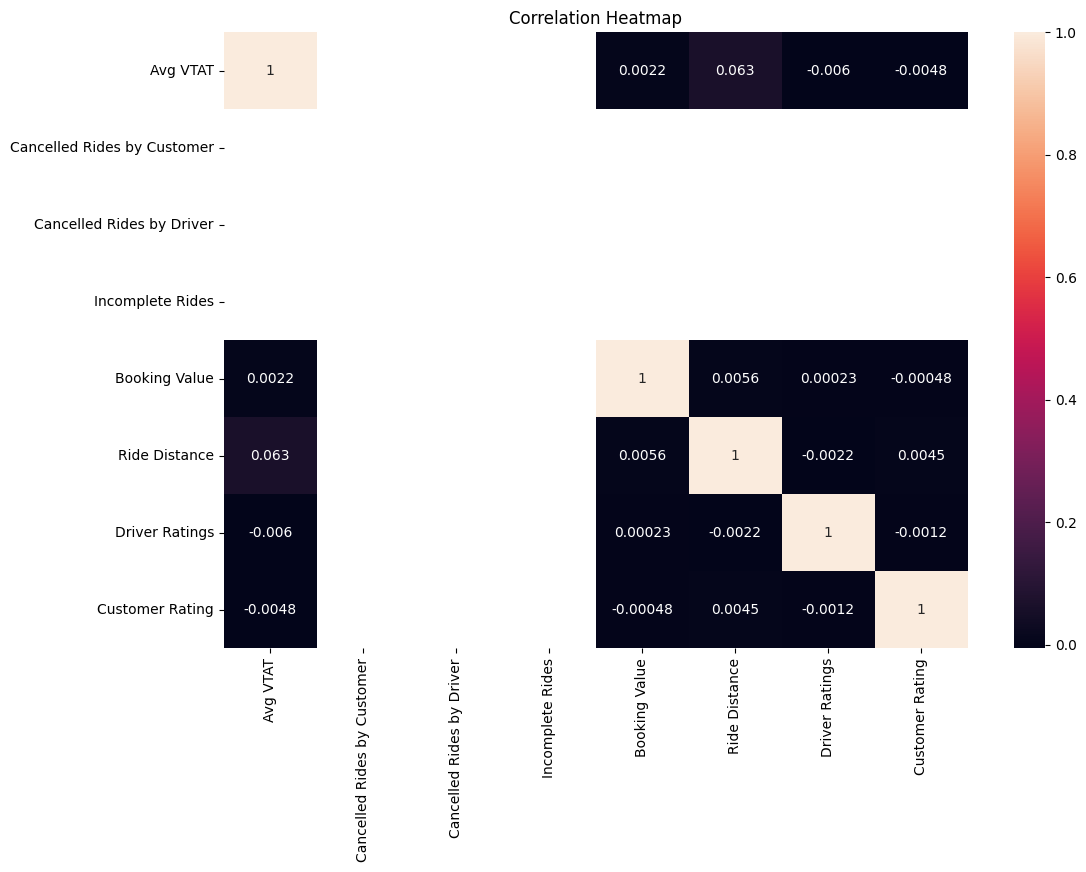

In [29]:
import seaborn as sns

num = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))

sns.heatmap(num.corr(),
            annot=True)

plt.title('Correlation Heatmap')

plt.show()

In [30]:
fig = px.box(
    df,
    y='Ride Distance',
    title='Ride Distance Analysis'
)

fig.show()

In [31]:
df['Date']=pd.to_datetime(df['Date'])

daily=df.groupby('Date').size().reset_index(name='Rides')

fig=px.area(
    daily,
    x='Date',
    y='Rides',
    title='Daily Ride Trend'
)

fig.show()

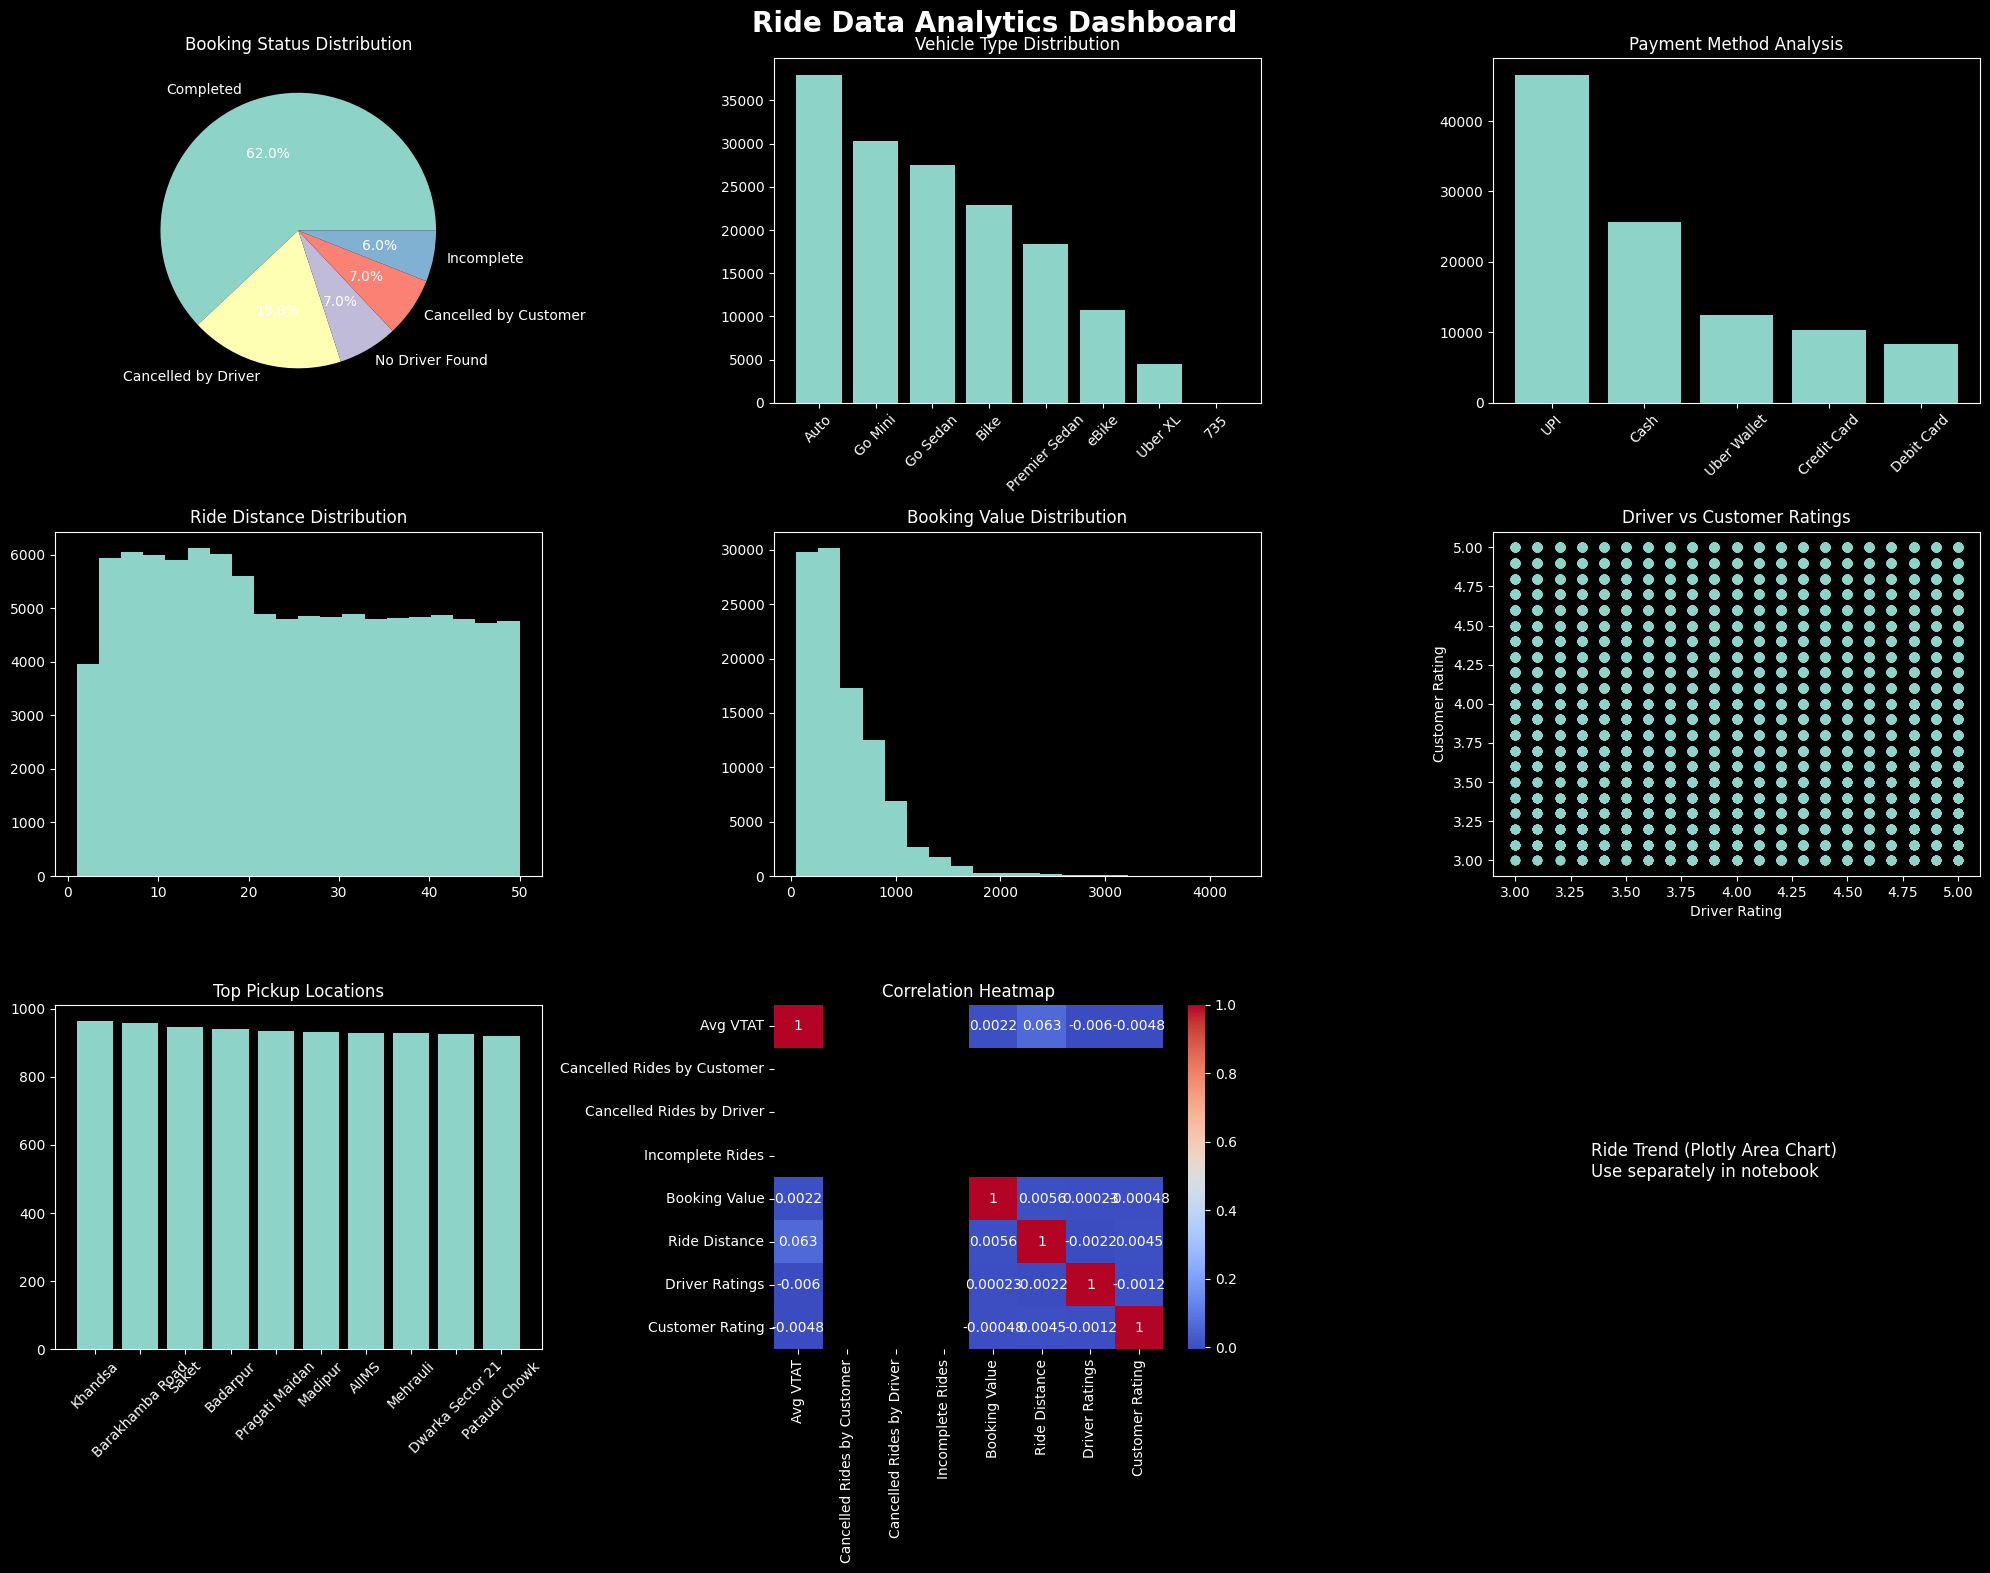

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme
plt.style.use('dark_background')

fig = plt.figure(figsize=(20, 16))
fig.suptitle("Ride Data Analytics Dashboard", fontsize=20, color='white', fontweight='bold')

# ---------------- 1. Booking Status Pie ----------------
ax1 = plt.subplot(3, 3, 1)
status = df['Booking Status'].value_counts()
ax1.pie(status.values, labels=status.index, autopct='%1.1f%%')
ax1.set_title("Booking Status Distribution")

# ---------------- 2. Vehicle Type ----------------
ax2 = plt.subplot(3, 3, 2)
vehicle = df['Vehicle Type'].value_counts()
ax2.bar(vehicle.index, vehicle.values)
ax2.set_title("Vehicle Type Distribution")
ax2.tick_params(axis='x', rotation=45)

# ---------------- 3. Payment Method ----------------
ax3 = plt.subplot(3, 3, 3)
payment = df['Payment Method'].value_counts()
ax3.bar(payment.index, payment.values)
ax3.set_title("Payment Method Analysis")
ax3.tick_params(axis='x', rotation=45)

# ---------------- 4. Ride Distance ----------------
ax4 = plt.subplot(3, 3, 4)
ax4.hist(df['Ride Distance'].dropna(), bins=20)
ax4.set_title("Ride Distance Distribution")

# ---------------- 5. Booking Value ----------------
ax5 = plt.subplot(3, 3, 5)
ax5.hist(df['Booking Value'].dropna(), bins=20)
ax5.set_title("Booking Value Distribution")

# ---------------- 6. Ratings Scatter ----------------
ax6 = plt.subplot(3, 3, 6)
ax6.scatter(df['Driver Ratings'], df['Customer Rating'])
ax6.set_title("Driver vs Customer Ratings")
ax6.set_xlabel("Driver Rating")
ax6.set_ylabel("Customer Rating")

# ---------------- 7. Pickup Locations ----------------
ax7 = plt.subplot(3, 3, 7)
pickup = df['Pickup Location'].value_counts().head(10)
ax7.bar(pickup.index, pickup.values)
ax7.set_title("Top Pickup Locations")
ax7.tick_params(axis='x', rotation=45)

# ---------------- 8. Correlation Heatmap ----------------
ax8 = plt.subplot(3, 3, 8)
num = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', ax=ax8)
ax8.set_title("Correlation Heatmap")

# ---------------- 9. Hide empty or add text ----------------
ax9 = plt.subplot(3, 3, 9)
ax9.text(0.2, 0.5, "Ride Trend (Plotly Area Chart)\nUse separately in notebook", fontsize=12)
ax9.axis('off')

plt.tight_layout()
plt.show()